In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_minimum_distances)=
# Get minimum distances

*Calculating minimum spatial distances between atom selections or molecular groups.*

The function {func}`molsysmt.structure.get_minimum_distances` calculates the closest distance and identifies the closest atom pair between two groups of atoms across single or multiple trajectory structures.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_minimum_distances`.
:::


## Basic usage

Let's show how to calculate the minimum distance between terminal residues over a pentalanine trajectory:


In [2]:
import molsysmt as msm
import matplotlib.pyplot as plt
import pyunitwizard as puw


In [3]:
molsys = msm.convert(msm.systems['pentalanine']['traj_pentalanine.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We compute the minimum distance between the first residue (index 0) and the last residue (index 4) using {func}`molsysmt.structure.get_minimum_distances`:


In [4]:
pairs, min_distances = msm.structure.get_minimum_distances(molsys, selection='group_index==0', selection_2='group_index==4')


In [5]:
print('Pairs array shape:', pairs.shape)
print('Minimum distances shape:', min_distances.shape)
print(f'Minimum distance at frame 0: {min_distances[0]:.3f} (between atom {pairs[0,0]} and {pairs[0,1]})')


Pairs array shape: (5000, 2)
Minimum distances shape: (5000,)
Minimum distance at frame 0: 0.823 nanometer (between atom 4 and 3)


## Plotting minimum distance time series

We plot the evolution of the minimum inter-residue distance over simulation time:


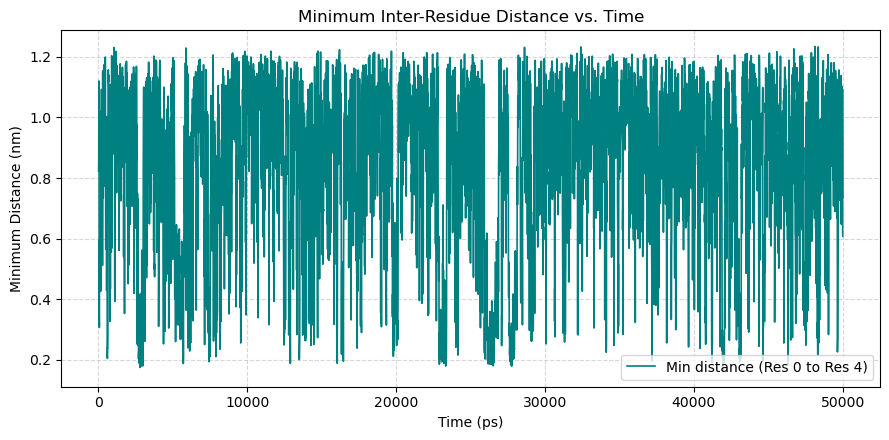

In [6]:
time = msm.get(molsys, element='system', time=True)
time_val = puw.get_value(time, to_unit='ps')
dist_val = puw.get_value(min_distances, to_unit='nm')

plt.figure(figsize=(9, 4.5))
plt.plot(time_val, dist_val, color='teal', lw=1.2, label='Min distance (Res 0 to Res 4)')
plt.xlabel('Time (ps)')
plt.ylabel('Minimum Distance (nm)')
plt.title('Minimum Inter-Residue Distance vs. Time')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


## Computing minimum distance between whole chains

We can compute the minimum spatial gap between two protein chains (such as chains A and B in TcTIM) to find their closest contact point:


In [7]:
tctim = msm.convert(msm.systems['TcTIM']['1tcd.h5msm'])
pairs_chains, min_dist_chains = msm.structure.get_minimum_distances(tctim, selection='chain_index==0 and atom_type!="H"', selection_2='chain_index==1 and atom_type!="H"')
print(f'Closest inter-chain contact distance: {min_dist_chains[0]:.3f}')
print(f'Closest atoms: chain 0 atom {pairs_chains[0,0]} and chain 1 atom {pairs_chains[0,1]}')


Closest inter-chain contact distance: 0.254 nanometer
Closest atoms: chain 0 atom 552 and chain 1 atom 729


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Get <Tutorial_Get>`: Query system time and structural attributes with {func}`molsysmt.basic.get`.
- {ref}`Get distances <Tutorial_Get_distances>`: Compute full pairwise distance matrices and element distances with {func}`molsysmt.structure.get_distances`.
- {ref}`Get maximum distances <Tutorial_Get_maximum_distances>`: Find the maximum span or diameter between elements with {func}`molsysmt.structure.get_maximum_distances`.
- {ref}`Get contacts <Tutorial_Get_contacts>`: Determine boolean contact matrices within a distance threshold with {func}`molsysmt.structure.get_contacts`.
:::
